In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
X_train = pd.read_csv("./Training Data/diabetes_XTrain.csv")
Y_train = pd.read_csv("./Training Data/diabetes_YTrain.csv")

In [5]:
#Load Training Dataset

print(X_train.shape)
print(Y_train.shape)

(576, 8)
(576, 1)


In [6]:
print(X_train.head())
print(Y_train.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            7      168             88             42      321  38.2   
1            8      110             76              0        0  27.8   
2            7      147             76              0        0  39.4   
3            2      100             66             20       90  32.9   
4            4      129             86             20      270  35.1   

   DiabetesPedigreeFunction  Age  
0                     0.787   40  
1                     0.237   58  
2                     0.257   43  
3                     0.867   28  
4                     0.231   23  
   Outcome
0        1
1        0
2        1
3        1
4        0


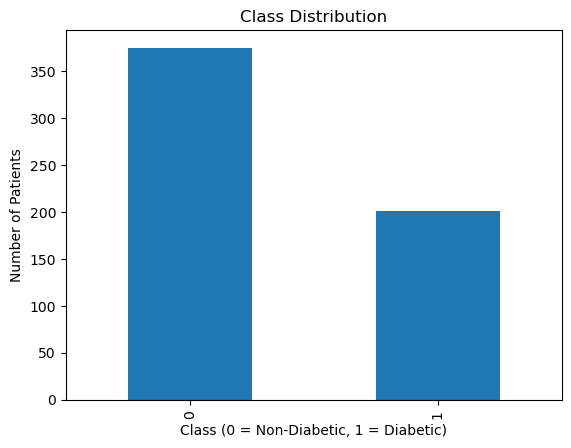

In [7]:
#Plot Bar Graph

Y_train['Outcome'].value_counts().plot(kind='bar')

plt.title("Class Distribution")
plt.xlabel("Class (0 = Non-Diabetic, 1 = Diabetic)")
plt.ylabel("Number of Patients")
plt.show()

In [8]:
#Convert Dataset Into NumPy Arrays

X = X_train.values
Y = Y_train.values.reshape(-1,)

In [9]:
#Load Test Dataset

X_test = pd.read_csv("./Testing Data/diabetes_XTest.csv")
X_test = X_test.values

In [10]:
#Define Distance Function

def distance(x1, x2):
    return np.sqrt(((x1 - x2)**2).sum())

In [11]:
#Create KNN Algorithm From Scratch

def knn(X, Y, queryPoint, k=5):

    vals = []

    for i in range(X.shape[0]):

        d = distance(queryPoint, X[i])
        vals.append((d, Y[i]))

    vals = sorted(vals)

    vals = vals[:k]

    vals = np.array(vals)

    labels = vals[:, 1]

    unique_vals, counts = np.unique(labels, return_counts=True)

    index = counts.argmax()

    prediction = unique_vals[index]

    return prediction

In [12]:
#Predict Test Dataset

predictions = []

for i in range(X_test.shape[0]):

    pred = knn(X, Y, X_test[i])

    predictions.append(pred)

In [13]:
#convert list into array

predictions = np.array(predictions)

In [14]:
#Save Predictions as CSV

df = pd.DataFrame(predictions, columns=['Outcome'])

df.to_csv("diabetes_predictions.csv", index=False)